In [4]:
import pandas as p
import matplotlib.pyplot as plt

df=p.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()
df.shape

(9994, 21)

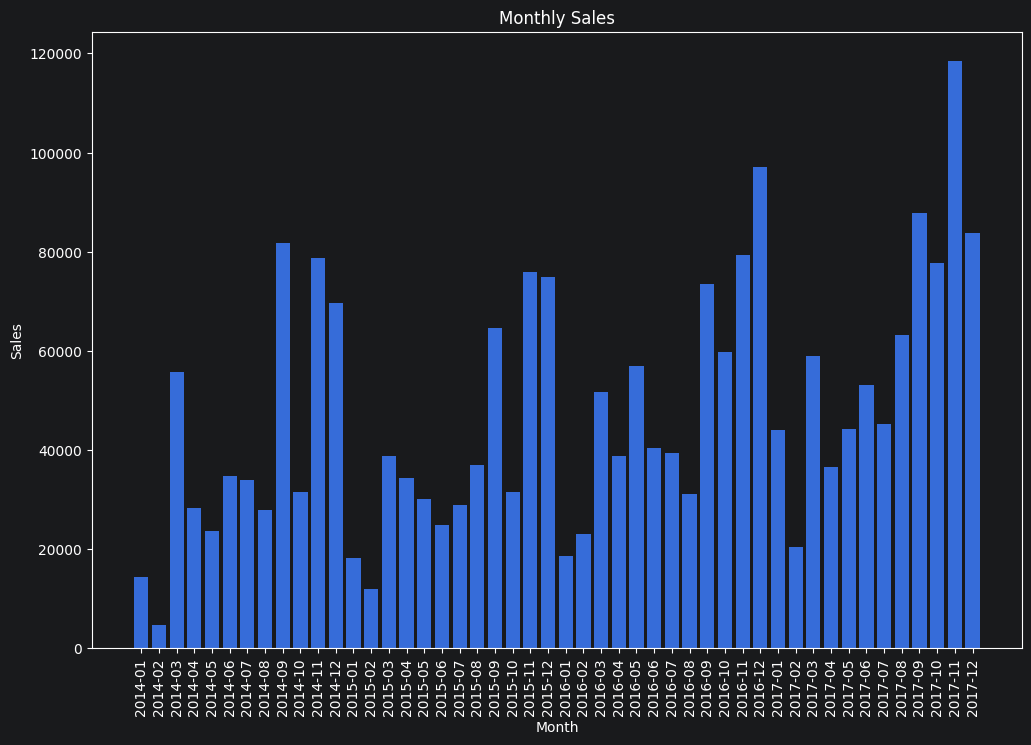

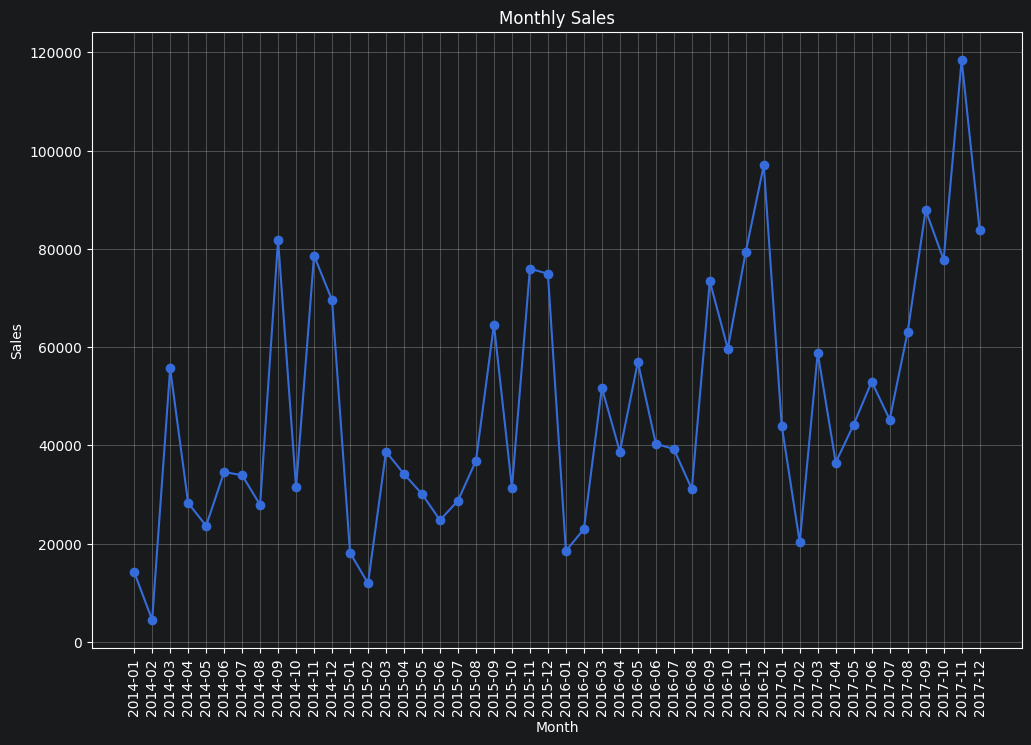

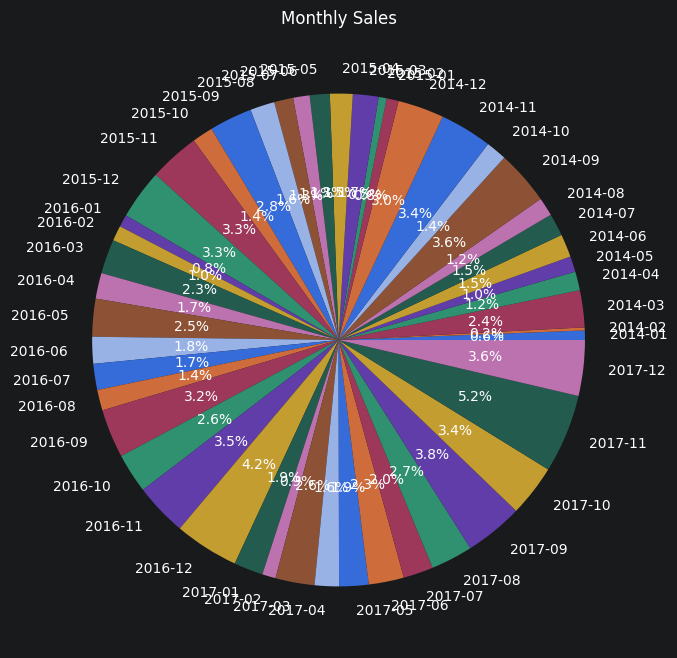

In [13]:
df['Order Date']=p.to_datetime(df['Order Date'])
monthly_sales=df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index=monthly_sales.index.astype(str)

monthly_sales

plt.figure(figsize=(12,8))
plt.bar(monthly_sales.index,monthly_sales.values)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=90)

plt.show()

plt.figure(figsize=(12,8))
plt.plot(monthly_sales.index,monthly_sales.values, marker='o')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=90)

plt.grid(True)
plt.show()

plt.figure(figsize=(12,8))
plt.pie(monthly_sales.values, labels=monthly_sales.index, autopct='%1.1f%%')

plt.title('Monthly Sales')
plt.show()

#line chart shows trend better due to the peaks visible
#bar chart shows it better too but not as good as line chart
#pie chart becomes messy

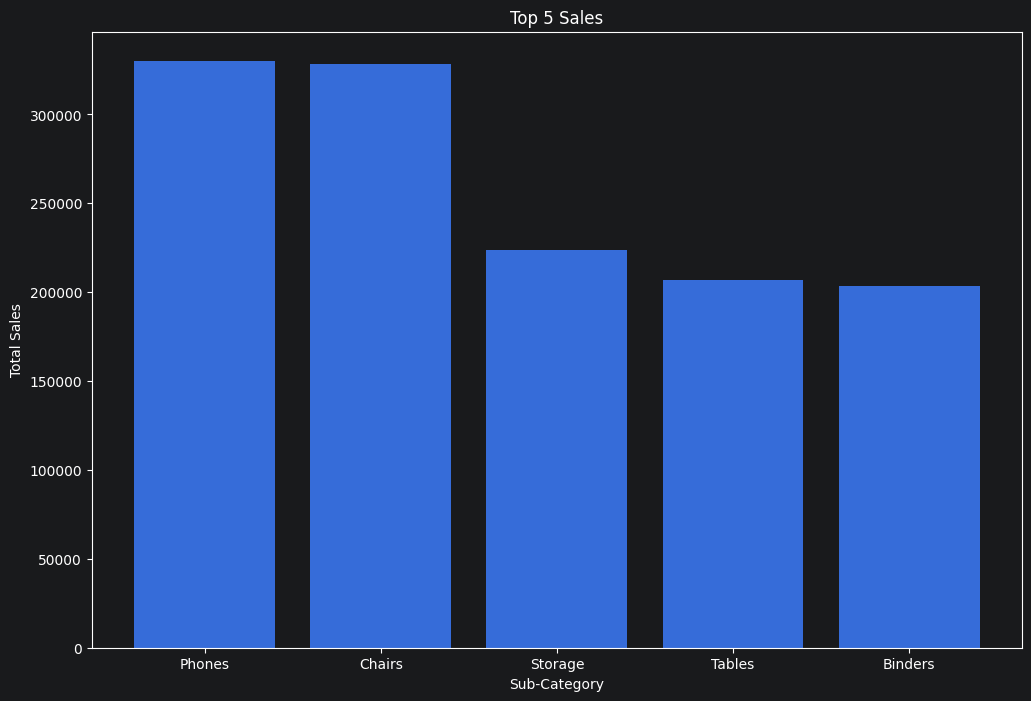

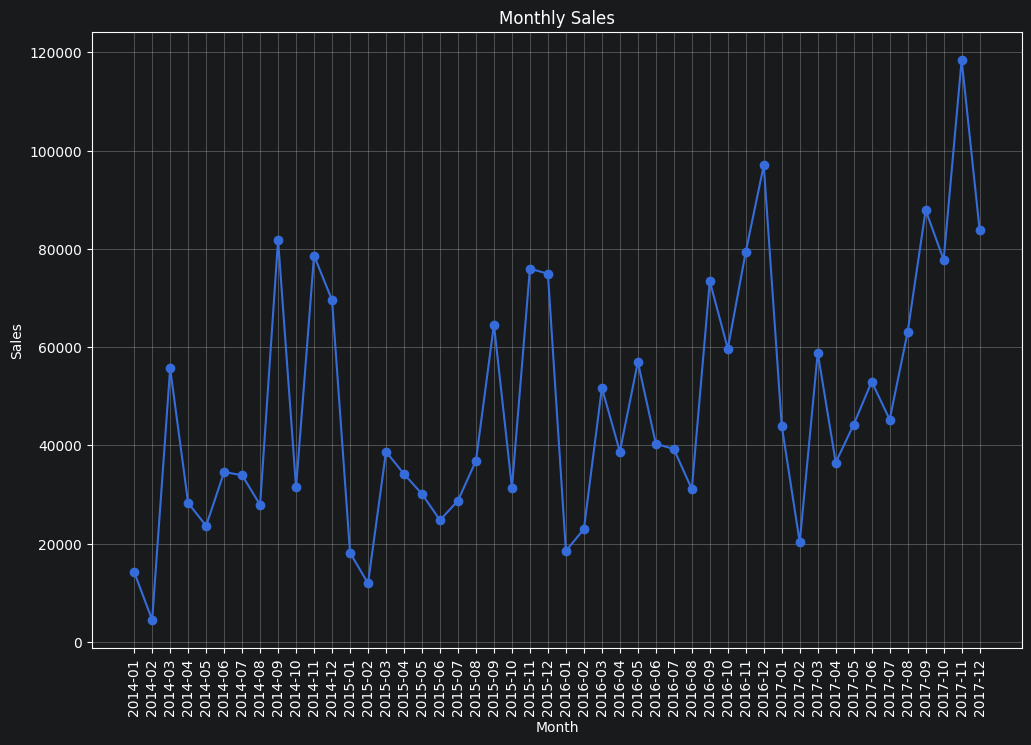

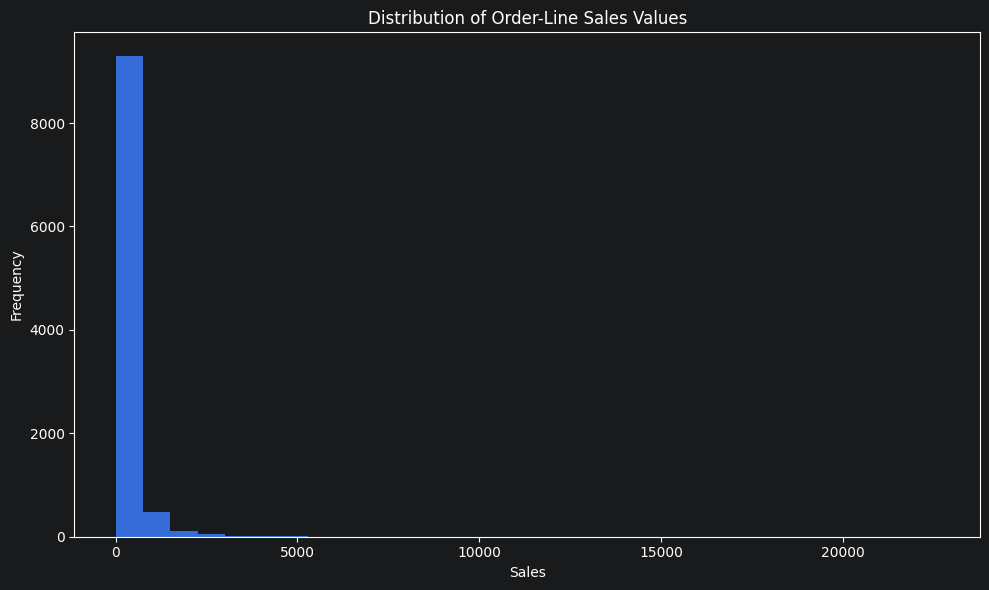

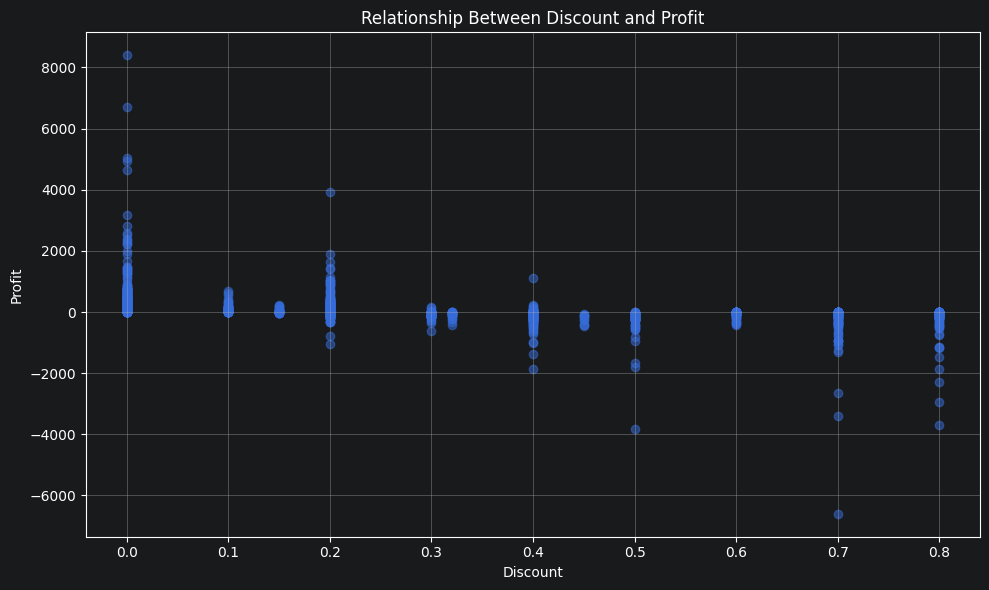

In [21]:
top5=df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)
top5

plt.figure(figsize=(12,8))
plt.bar(top5.index,top5.values)
plt.title('Top 5 Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')

plt.show()

#bar shows the total of each categ in a cleaner way, but pie chart would have similar slices and length would not be comparable

df['Order Date']=p.to_datetime(df['Order Date'])
monthly_sales=df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(12,8))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values, marker='o')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=90)
plt.grid(True)
plt.show()

#line chart better because it shows the trends while it would be difficult to depict those in a pie chart

plt.figure(figsize=(10, 6))

plt.hist(df['Sales'], bins=30)

plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#histogram shows the proper shape of the distribution, and since its numerical so bar charts would not be a good choice


plt.figure(figsize=(10, 6))

plt.scatter(df['Discount'], df['Profit'], alpha=0.5)

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True)

plt.tight_layout()
plt.show()

#scatter allows to see outliers and clusters easily, bar chart would hide such patterns and observations

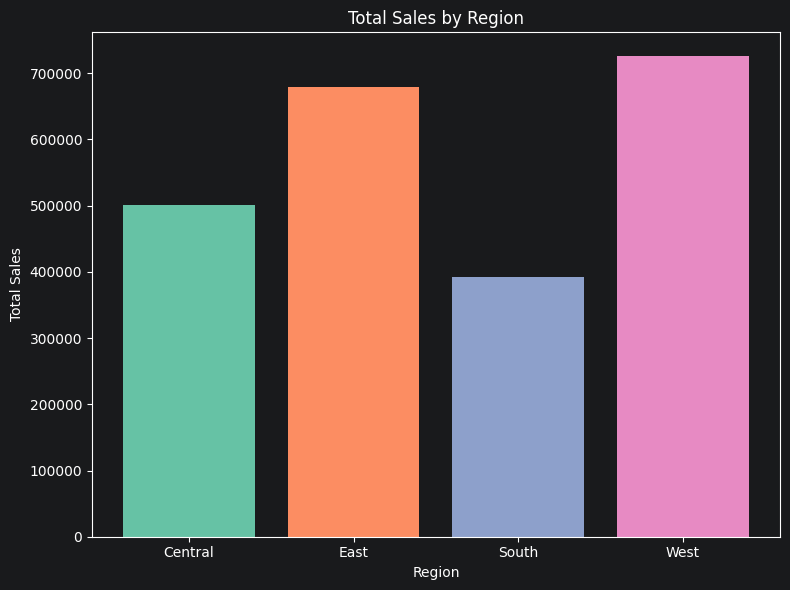

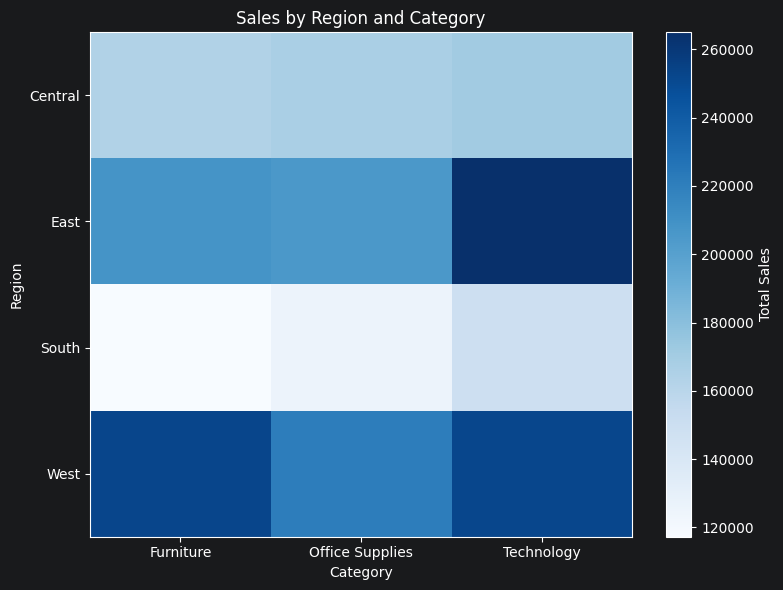

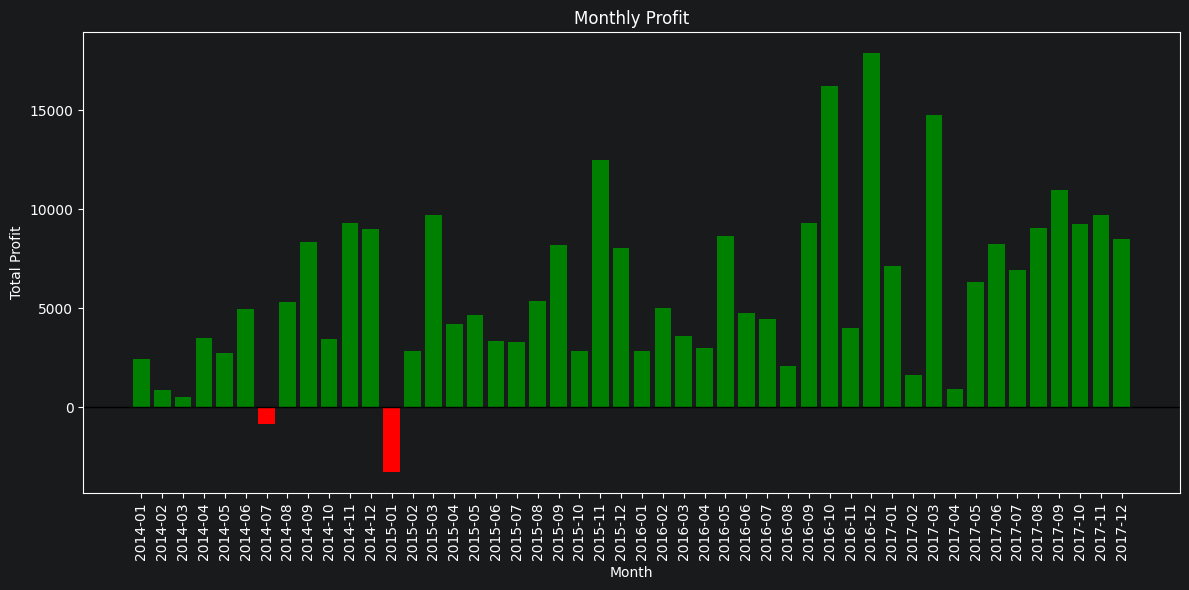

In [26]:
#part a

region_sales = df.groupby('Region')['Sales'].sum()
region_sales

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.bar(region_sales.index,region_sales.values,color=plt.cm.Set2(range(len(region_sales))))

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()


#part b

region_category_sales = df.pivot_table(values='Sales',index='Region',columns='Category',aggfunc='sum')

plt.figure(figsize=(8, 6))

plt.imshow(region_category_sales,cmap='Blues',aspect='auto')

plt.colorbar(label='Total Sales')

plt.xticks(range(len(region_category_sales.columns)),region_category_sales.columns)

plt.yticks(range(len(region_category_sales.index)),region_category_sales.index)

plt.title('Sales by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

#part c

monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()

monthly_profit

plt.figure(figsize=(12, 6))

colors = ['red' if value < 0 else 'green' for value in monthly_profit.values]

plt.bar(monthly_profit.index.astype(str),monthly_profit.values,color=colors)

plt.axhline(0, color='black', linewidth=1)

plt.title('Monthly Profit')
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [29]:
def contrast_ratio(color1, color2):
    def relative_luminance(rgb):
        rgb = [value / 255 for value in rgb]

        linear = []
        for value in rgb:
            if value <= 0.03928:
                linear.append(value / 12.92)
            else:
                linear.append(((value + 0.055) / 1.055) ** 2.4)

        return (
            0.2126 * linear[0] +
            0.7152 * linear[1] +
            0.0722 * linear[2]
        )

    L1 = relative_luminance(color1)
    L2 = relative_luminance(color2)

    # Higher luminance should be on top
    lighter = max(L1, L2)
    darker = min(L1, L2)

    return (lighter + 0.05) / (darker + 0.05)

ratio = contrast_ratio((0, 0, 0), (255, 255, 255))

print("Contrast ratio:", round(ratio, 2))

if ratio >= 4.5:
    print("PASS - Meets WCAG AA")
else:
    print("FAIL - Does not meet WCAG AA")

red = (255, 0, 0)
green = (0, 128, 0)
white = (255, 255, 255)

print("Red vs White:", round(contrast_ratio(red, white), 2))

print("Green vs White:", round(contrast_ratio(green, white), 2))

colors = {
    "Red": red,
    "Green": green
}

for name, color in colors.items():
    ratio = contrast_ratio(color, white)

    if ratio >= 4.5:
        print(name, ":", round(ratio, 2), "PASS")
    else:
        print(name, ":", round(ratio, 2), "FAIL")

Contrast ratio: 21.0
PASS - Meets WCAG AA
Red vs White: 4.0
Green vs White: 5.14
Red : 4.0 FAIL
Green : 5.14 PASS


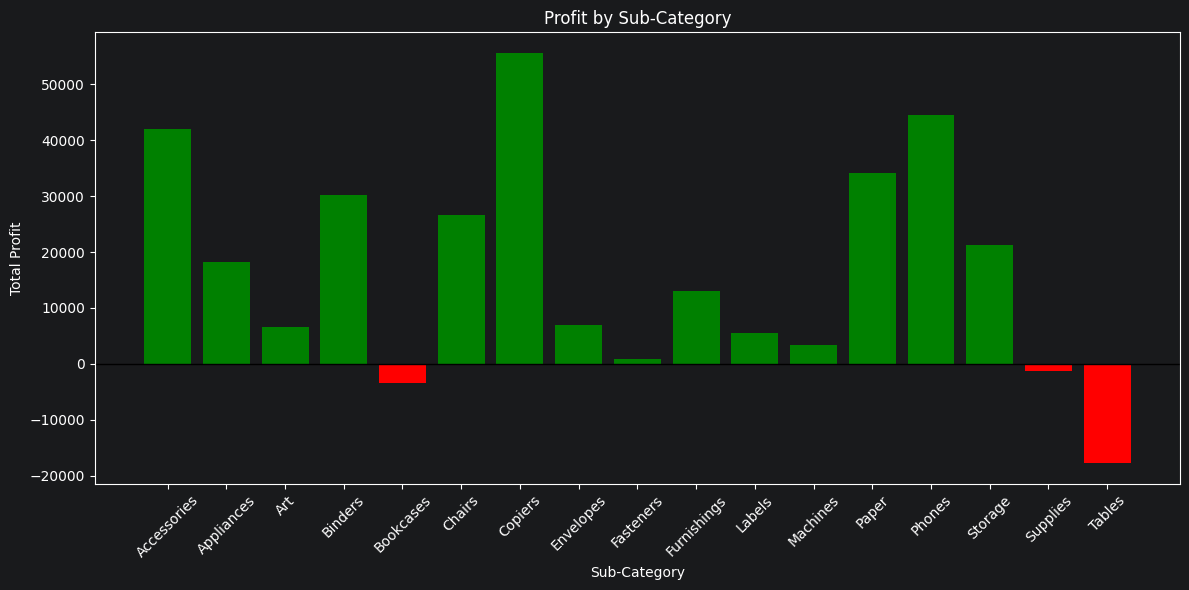

In [30]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

subcategory_profit

colors = ['green' if value >= 0 else 'red'
          for value in subcategory_profit.values]

plt.figure(figsize=(12, 6))

plt.bar(
    subcategory_profit.index,
    subcategory_profit.values,
    color=colors
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

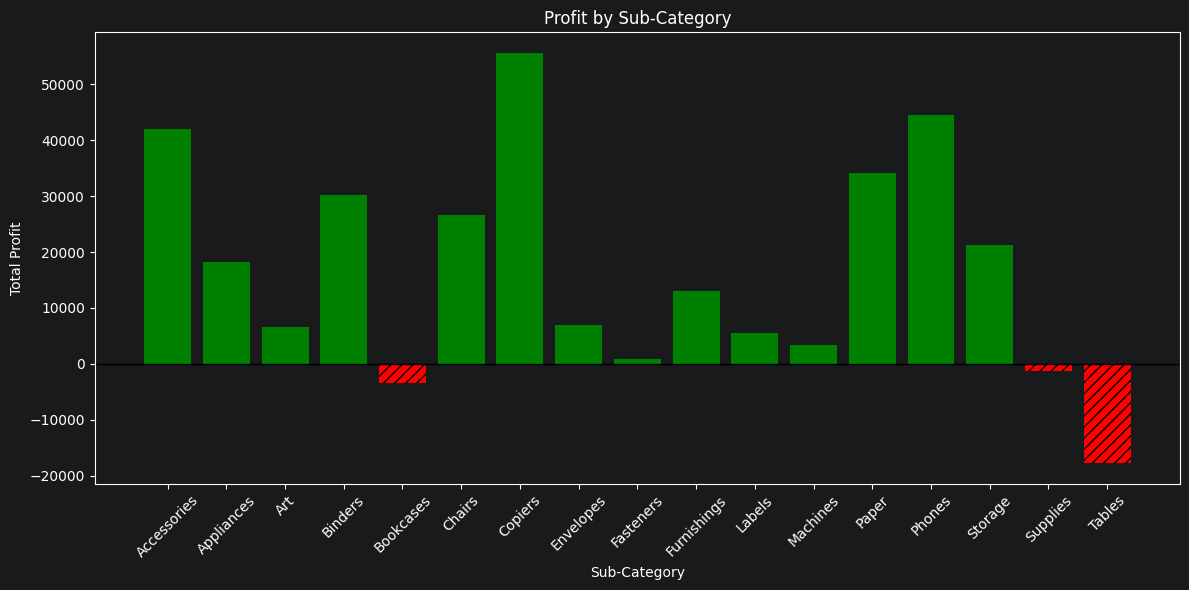

In [31]:
colors = ['green' if value >= 0 else 'red'
          for value in subcategory_profit.values]

hatches = ['///' if value < 0 else ''
           for value in subcategory_profit.values]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    subcategory_profit.index,
    subcategory_profit.values,
    color=colors
)

for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

plt.axhline(0, color='black', linewidth=1)

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

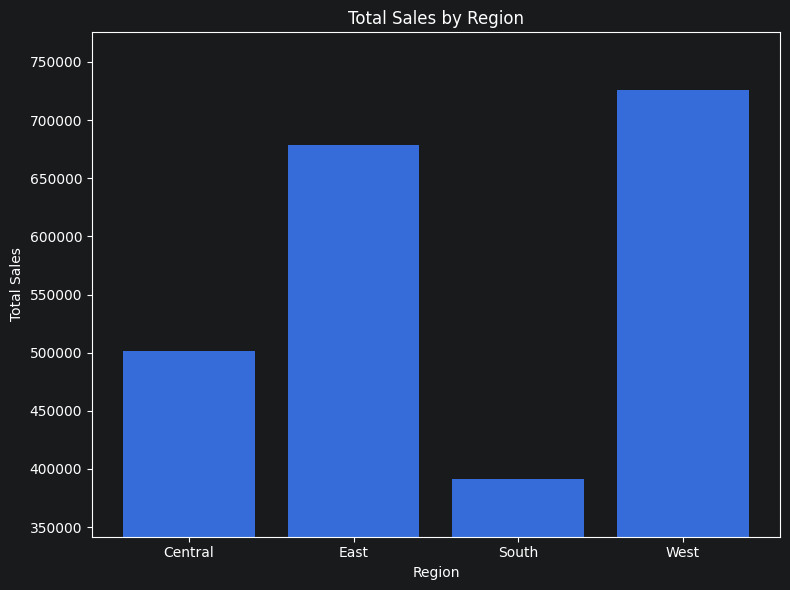

In [34]:
region_sales = df.groupby('Region')['Sales'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.bar(region_sales.index, region_sales.values)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

# TRUNCATED Y-AXIS
plt.ylim(region_sales.min() - 50000, region_sales.max() + 50000)

plt.tight_layout()
plt.show()

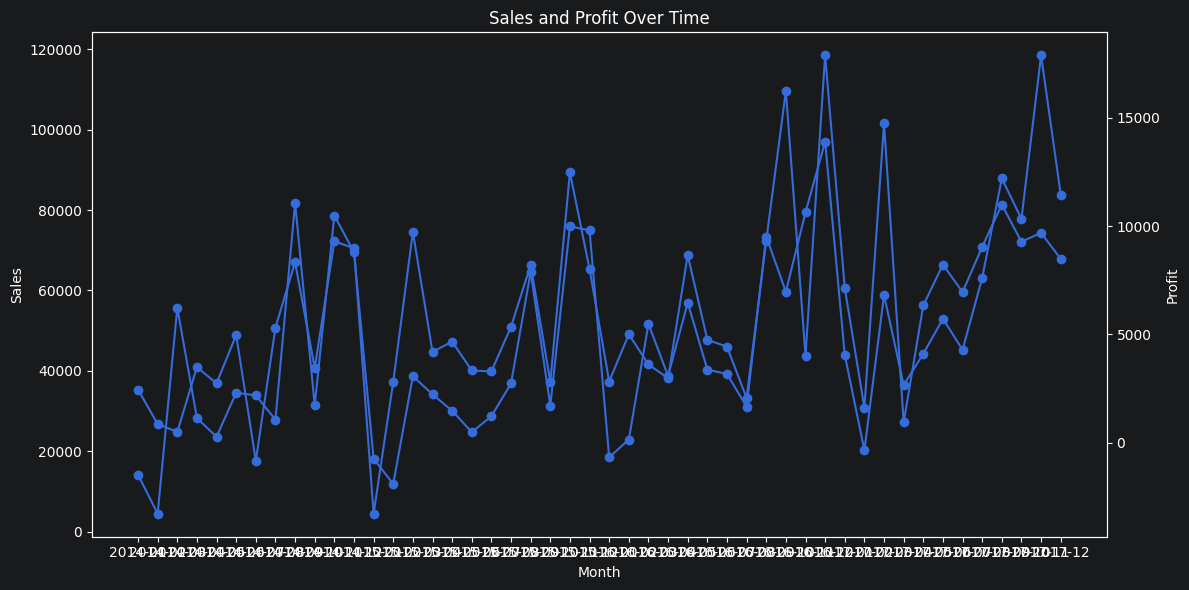

In [35]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales')

ax2 = ax1.twinx()

ax2.plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker='o'
)

ax2.set_ylabel('Profit')

plt.title('Sales and Profit Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

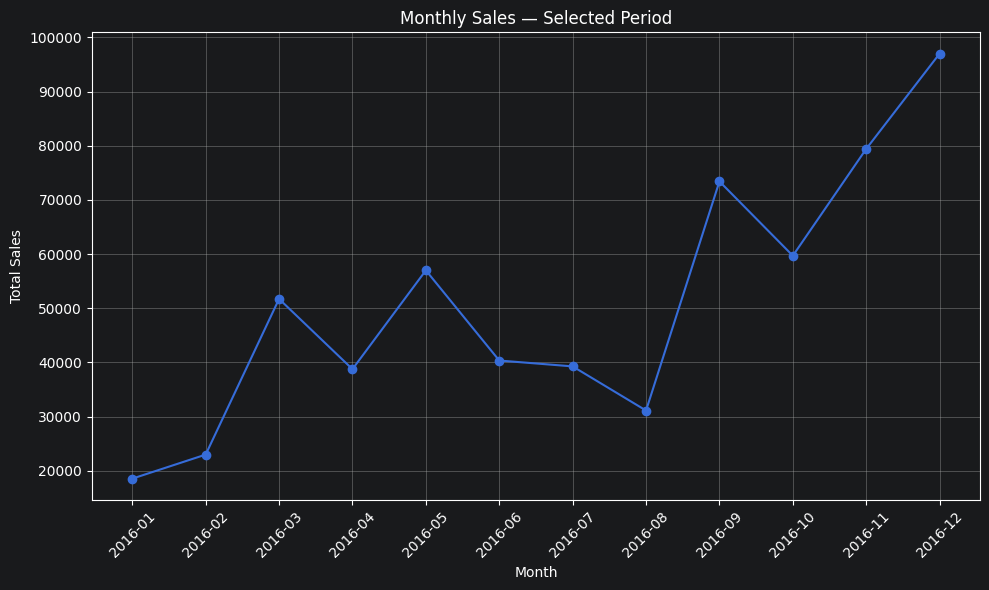

In [37]:
monthly_sales_2016 = monthly_sales[
    monthly_sales.index.astype(str).str.startswith('2016')
]

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales_2016.index.astype(str),
    monthly_sales_2016.values,
    marker='o'
)

plt.title('Monthly Sales — Selected Period')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


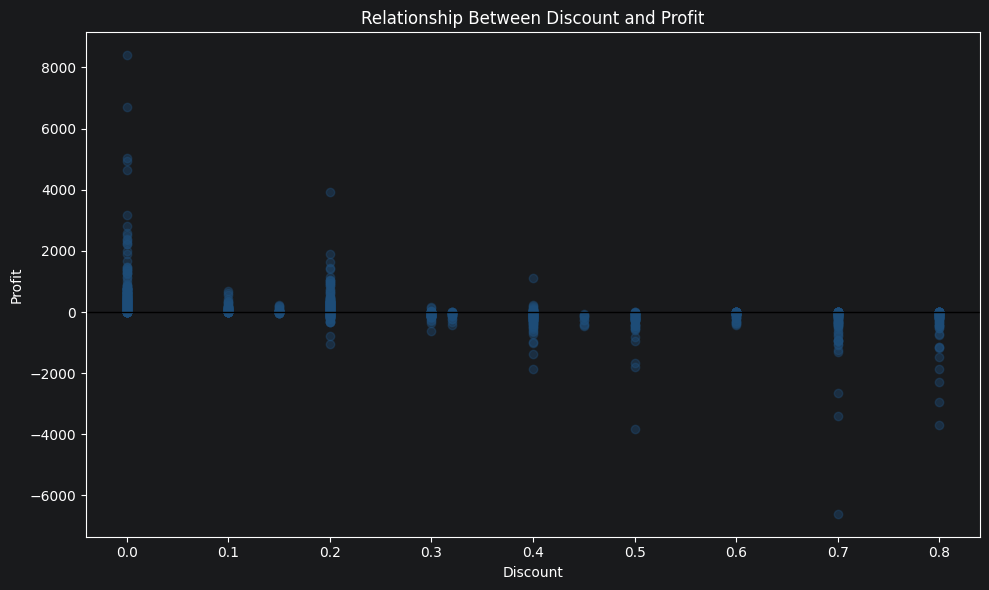

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4,
    color='#1f4e79'
)

plt.axhline(0, color='black', linewidth=1)

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

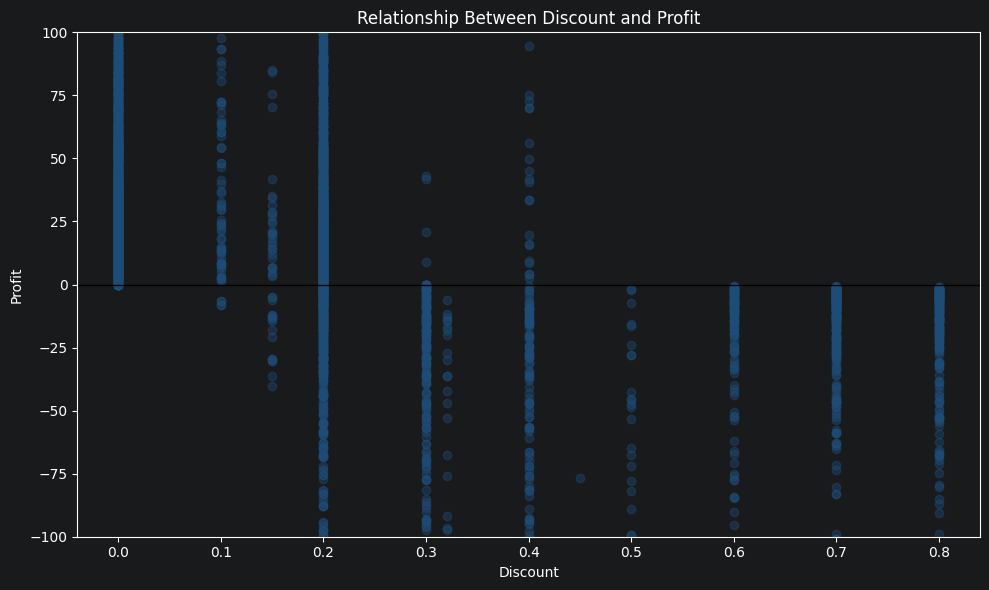

In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4,
    color='#1f4e79'
)

plt.axhline(0, color='black', linewidth=1)

plt.ylim(-100, 100)

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()